# EDA multivariada entre poluentes - Rio de Janeiro

## Objetivo
Avaliar relacoes entre poluentes da serie diaria consolidada, cobrindo:
- matriz de correlacao,
- heatmap e analise de colinearidade,
- agrupamento de variaveis com comportamento parecido.


## 1. Importacoes e configuracoes


In [7]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

URL_DADOS = (
    "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/"
    "refs/heads/Refactoring-And-Documentation/"
    "Data/IntermediaryData/MonitorAr/DailyQualiarRj/"
    "serie_diaria_qualidade_ar_rio_de_janeiro.csv"
)

COLUNA_DATA = "data"
LIMIAR_CORRELACAO_FORTE = 0.80
LIMIAR_CLUSTER_CORR = 0.65

POLUENTES_CANDIDATOS: List[str] = [
    "pm10",
    "pm2_5",
    "o3",
    "no2",
    "so2",
    "co",
    "pts",
    "no",
    "nox",
]

## 2. Carregamento da base


In [8]:
df_rj = pd.read_csv(URL_DADOS, parse_dates=[COLUNA_DATA])
df_rj[COLUNA_DATA] = pd.to_datetime(df_rj[COLUNA_DATA], errors="coerce").dt.normalize()
df_rj = df_rj.dropna(subset=[COLUNA_DATA]).sort_values(COLUNA_DATA).reset_index(drop=True)

print(f"Fonte usada: {URL_DADOS}")
print(f"Periodo: {df_rj[COLUNA_DATA].min():%Y-%m-%d} ate {df_rj[COLUNA_DATA].max():%Y-%m-%d}")
print(f"Dimensao: {df_rj.shape[0]:,} linhas x {df_rj.shape[1]:,} colunas")
display(df_rj.head())


Fonte usada: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/DailyQualiarRj/serie_diaria_qualidade_ar_rio_de_janeiro.csv
Periodo: 2012-01-01 ate 2018-12-31
Dimensao: 2,557 linhas x 12 colunas


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,5.762,22.376,2.667,14.508,28.102,92.521,25.556,22.905,0.397,22.838,228.2
1,2012-01-02,25.347,29.317,2.290,8.158,54.670,95.074,22.264,13.924,0.311,14.965,371.0
2,2012-01-03,23.367,28.593,3.704,9.875,51.883,73.642,25.091,15.997,0.243,26.374,0.2
3,2012-01-04,28.645,36.209,3.177,14.823,64.833,72.631,26.083,23.245,0.267,35.924,0.4
4,2012-01-05,17.859,31.785,3.113,11.958,49.605,74.860,26.661,36.343,0.250,31.761,0.0


## 3. Selecionar poluentes para EDA multivariada


In [9]:
colunas_numericas = df_rj.select_dtypes(include="number").columns.tolist()
poluentes = [v for v in POLUENTES_CANDIDATOS if v in colunas_numericas]

if len(poluentes) < 2:
    raise RuntimeError("Sao necessarias ao menos 2 variaveis de poluente para EDA multivariada.")

# Base de poluentes com listwise deletion para manter comparabilidade entre metodos.
df_poluentes = df_rj[[COLUNA_DATA] + poluentes].copy()
df_poluentes_modelo = df_poluentes.dropna(subset=poluentes).copy()

print(f"Poluentes selecionados: {poluentes}")
print(f"Linhas com dados completos para modelagem: {len(df_poluentes_modelo):,}")
display(df_poluentes_modelo.head())


Poluentes selecionados: ['pm10', 'pm2_5', 'o3', 'no2', 'so2', 'co', 'no', 'nox']
Linhas com dados completos para modelagem: 2,516


,data,pm10,pm2_5,o3,no2,so2,co,no,nox
0,2012-01-01,22.838,14.508,22.905,22.376,2.667,0.397,5.762,28.102
1,2012-01-02,14.965,8.158,13.924,29.317,2.290,0.311,25.347,54.670
2,2012-01-03,26.374,9.875,15.997,28.593,3.704,0.243,23.367,51.883
3,2012-01-04,35.924,14.823,23.245,36.209,3.177,0.267,28.645,64.833
4,2012-01-05,31.761,11.958,36.343,31.785,3.113,0.250,17.859,49.605


## 4. Matriz de correlacao entre poluentes


In [10]:
# Correlacao linear (Pearson) e monotonia (Spearman) para visoes complementares.
matriz_corr_pearson = df_poluentes_modelo[poluentes].corr(method="pearson")
matriz_corr_spearman = df_poluentes_modelo[poluentes].corr(method="spearman")

print("Matriz de correlacao Pearson:")
display(matriz_corr_pearson.round(3))

print("Matriz de correlacao Spearman:")
display(matriz_corr_spearman.round(3))


Matriz de correlacao Pearson:


,pm10,pm2_5,o3,no2,so2,co,no,nox
pm10,1.000,0.848,0.200,0.634,0.574,0.668,0.434,0.584
pm2_5,0.848,1.000,0.102,0.609,0.501,0.742,0.475,0.592
o3,0.200,0.102,1.000,-0.173,0.192,-0.126,-0.490,-0.362
no2,0.634,0.609,-0.173,1.000,0.460,0.689,0.671,0.915
so2,0.574,0.501,0.192,0.460,1.000,0.514,0.342,0.438
co,0.668,0.742,-0.126,0.689,0.514,1.000,0.653,0.733
no,0.434,0.475,-0.490,0.671,0.342,0.653,1.000,0.913
nox,0.584,0.592,-0.362,0.915,0.438,0.733,0.913,1.000


Matriz de correlacao Spearman:


,pm10,pm2_5,o3,no2,so2,co,no,nox
pm10,1.000,0.814,0.223,0.573,0.586,0.586,0.301,0.500
pm2_5,0.814,1.000,0.140,0.549,0.514,0.710,0.302,0.489
o3,0.223,0.140,1.000,-0.176,0.177,-0.093,-0.589,-0.383
no2,0.573,0.549,-0.176,1.000,0.455,0.642,0.654,0.928
so2,0.586,0.514,0.177,0.455,1.000,0.507,0.290,0.421
co,0.586,0.710,-0.093,0.642,0.507,1.000,0.480,0.630
no,0.301,0.302,-0.589,0.654,0.290,0.480,1.000,0.877
nox,0.500,0.489,-0.383,0.928,0.421,0.630,0.877,1.000


## 5. Heatmap e analise de colinearidade


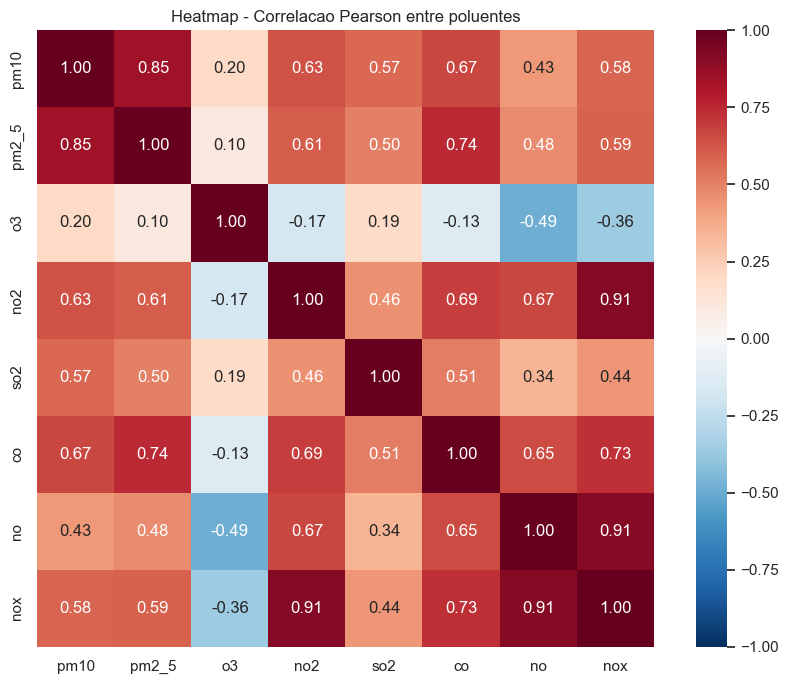

Pares com |correlacao| >= 0.80:


,variavel_1,variavel_2,correlacao,abs_correlacao,flag_redundancia
1,no2,nox,0.914696,0.914696,alta
2,no,nox,0.913081,0.913081,alta
0,pm10,pm2_5,0.848249,0.848249,alta


,variavel,vif,r2_aux
7,nox,2360.406,1.000
3,no2,716.903,0.999
6,no,703.019,0.999
0,pm10,4.559,0.781
1,pm2_5,4.485,0.777
5,co,3.295,0.697
2,o3,1.944,0.485
4,so2,1.679,0.405


In [11]:
# Heatmap da correlacao de Pearson.
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)

plt.title("Heatmap - Correlacao Pearson entre poluentes")
plt.tight_layout()
plt.show()

# Identifica pares potencialmente redundantes por correlacao absoluta alta.
pares_redundantes = []
for i, var_i in enumerate(poluentes):
    for j, var_j in enumerate(poluentes):
        if j <= i:
            continue

        corr_ij = float(matriz_corr_pearson.loc[var_i, var_j])
        if abs(corr_ij) >= LIMIAR_CORRELACAO_FORTE:
            pares_redundantes.append(
                {
                    "variavel_1": var_i,
                    "variavel_2": var_j,
                    "correlacao": corr_ij,
                    "abs_correlacao": abs(corr_ij),
                    "flag_redundancia": "alta",
                }
            )

# Tabela de pares com alta redundancia.
tabela_redundancia = pd.DataFrame(pares_redundantes).sort_values(
    by="abs_correlacao", ascending=False
) if pares_redundantes else pd.DataFrame(
    columns=["variavel_1", "variavel_2", "correlacao", "abs_correlacao", "flag_redundancia"]
)

print(f"Pares com |correlacao| >= {LIMIAR_CORRELACAO_FORTE:.2f}:")
display(tabela_redundancia)


def calcular_vif(df: pd.DataFrame) -> pd.DataFrame:
    # Calcula VIF sem dependencia de statsmodels.
    # VIF = 1 / (1 - R2), onde cada variavel e regressada nas demais.
    colunas = list(df.columns)
    registros = []

    for alvo in colunas:
        outras = [c for c in colunas if c != alvo]

        if not outras:
            registros.append({"variavel": alvo, "vif": np.nan, "r2_aux": np.nan})
            continue

        y = df[alvo].values.astype(float)
        X = df[outras].values.astype(float)
        X = np.column_stack([np.ones(len(X)), X])

        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_pred = X @ beta

        ss_res = float(np.sum((y - y_pred) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        registros.append({"variavel": alvo, "vif": vif, "r2_aux": r2})

    return pd.DataFrame(registros).sort_values(by="vif", ascending=False)


# VIF para diagnosticar multicolinearidade global.
tabela_vif = calcular_vif(df_poluentes_modelo[poluentes]).round(3)
display(tabela_vif)
